# 04. Model Evaluation & Comparison
Notebook ini difokuskan pada evaluasi mendalam terhadap model terbaik yang dipilih dari fase eksperimen (Notebook 03), analisis interpretasi (SHAP), tuning threshold, dan serialisasi model untuk tahap *production*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

### 1. Load Data Splits (Engineered Features)
Kita menggunakan data hasil feature engineering yang sudah dibagi pada Notebook 02.

In [2]:
# Path disesuaikan karena posisi notebook ada di experiments/notebooks/
X_train = pd.read_csv('../data/splits/X_train_eng.csv')
X_test = pd.read_csv('../data/splits/X_test_eng.csv')
y_train = pd.read_csv('../data/splits/y_train_eng.csv').values.ravel()
y_test = pd.read_csv('../data/splits/y_test_eng.csv').values.ravel()

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (37518, 25)
Shape X_test: (9380, 25)


### 2. Train Final Model (Random Forest)
Berdasarkan eksperimen di Notebook 03, Random Forest dan model tree-based lainnya memberikan performa mendekati 100%. Kita menggunakan RandomForestClassifier murni dari `sklearn` karena lebih ringan dan lebih mudah diinterpretasi untuk *production* dibandingkan membungkusnya dalam *pipeline* PyCaret.

In [3]:
print("Training final Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training completed.")

Training final Random Forest model...


Training completed.


### 3. Deep Evaluation Metrics

Classification Report:
               precision    recall  f1-score   support

 Standard (0)       1.00      1.00      1.00      5145
Optimized (1)       1.00      1.00      1.00      4235

     accuracy                           1.00      9380
    macro avg       1.00      1.00      1.00      9380
 weighted avg       1.00      1.00      1.00      9380

ROC-AUC Score: 1.0000


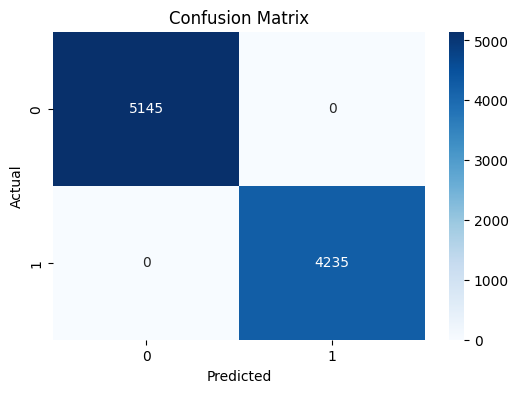

In [4]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Standard (0)', 'Optimized (1)']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 4. Threshold Tuning Analysis
Dalam konteks operasional pabrik/mesin, *False Positives* (merekomendasikan Optimized padahal seharusnya Standard) mungkin lebih berbahaya atau sebaliknya. Kita menganalisis *trade-off* Precision dan Recall.

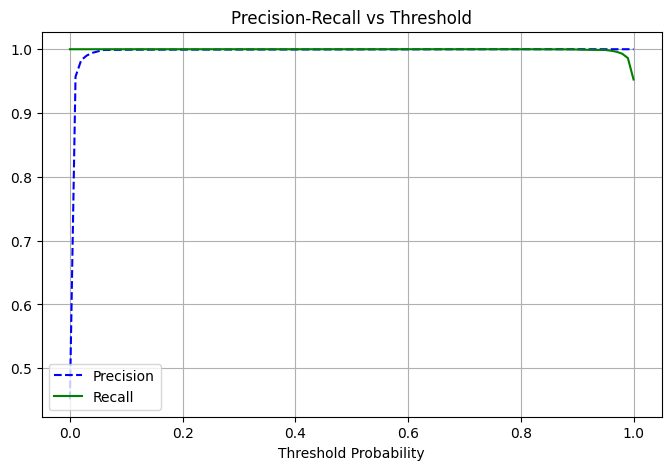

Business logic akan menggunakan Threshold: 0.5


In [5]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold Probability")
plt.legend(loc="lower left")
plt.title("Precision-Recall vs Threshold")
plt.grid()
plt.show()

# Berdasarkan performa data yang separable, threshold default 0.5 sudah sangat baik. 
# Jika diperlukan kehati-hatian ekstra, kita bisa menggunakan threshold 0.8 pada production engine.
OPTIMAL_THRESHOLD = 0.5
print(f"Business logic akan menggunakan Threshold: {OPTIMAL_THRESHOLD}")

### 5. Model Interpretability (SHAP)
Menjelaskan *feature* mana (sensor mana) yang paling mempengaruhi keputusan model.

Menghitung nilai SHAP (membutuhkan waktu sejenak)...


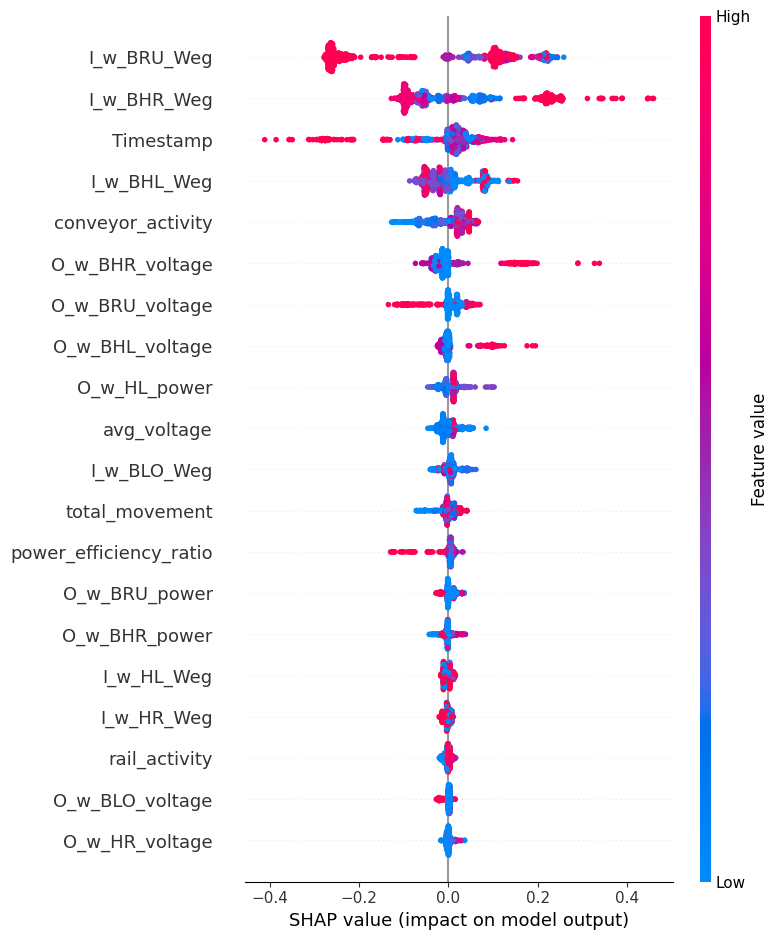

In [6]:
print("Menghitung nilai SHAP (membutuhkan waktu sejenak)...")
explainer = shap.TreeExplainer(rf_model)
# Menggunakan sampel untuk efisiensi plot
X_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Handle output compatibility issues with different SHAP versions
if isinstance(shap_values, list):
    shap_vals = shap_values[1] # Index 1 untuk probabilitas kelas 'Optimized'
elif len(shap_values.shape) == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

shap.summary_plot(shap_vals, X_sample)

### 6. Model Serialization
Menyimpan model ke direktori `models/` agar bisa digunakan oleh *Recommendation Engine* dan API.

In [7]:
os.makedirs("../../models", exist_ok=True)
model_path = "../../models/final_hrss_rf_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)
    
print(f"Model berhasil disimpan ke: {model_path}")

Model berhasil disimpan ke: ../../models/final_hrss_rf_model.pkl
